In [8]:
import os
import sys
# set working directory
os.chdir("../riemannian_la")
print(os.getcwd())

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from models import LinearModel, FunctionApproximatorModel
from train import train
from laplace_approx import Laplace
from MCMC_sampler import MCMC_sampler
from getdata import make_loaders, torch_seed, gen_model_data, gen_log_regression_data
from utils import NegLogLik_regression
from integration import integrator
from utils import loss_func_from_target_sigma, make_functional_fwd_xs, functional_loss, functional_loss_for_vmap, sum_loss, neglog_loss, tensify
from discrete_sampler import discrete_function_sampler, discrete_model_sampler
from riemann_sampler import Riemann_sampler, riemann_plotter
from BQ_rays_subspace import BayesianQuadrature_rays
from emukit.quadrature.methods import VanillaBayesianQuadrature, WarpedBayesianQuadratureModel, BoundedBayesianQuadrature
from emukit.quadrature.methods.warpings import SquareRootWarping
from emukit.model_wrappers import GPyModelWrapper
import numpy as np

fig_folder = "../report/figures"
os.makedirs(fig_folder, exist_ok=True)

/Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la


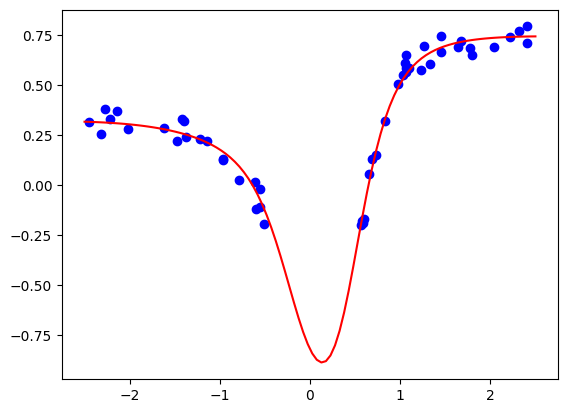

In [2]:
num_features=1
model = FunctionApproximatorModel(num_features=num_features, hidden_layers=[10,10], num_outputs=1, nonlin = torch.nn.Tanh(), seed=47)

prior_sigma = 1.
target_sigma = 0.05

start_x = -2.5
end_x = 2.5
#input_dist = lambda x: torch.rand(x, num_features)*(end_x-start_x) + start_x
def input_dist(N):
    xs = torch.rand(N*10, num_features)*(end_x-start_x) + start_x
    index = (1-((xs > -.5) & (xs < 0.5)).int()).nonzero()[:,0]
    return xs[index][:N]

train_loader, test_loader = gen_model_data(model, input_dist, num_train_samples=50, 
                                           num_test_samples=10, noise_std=target_sigma, seed=2, batch_size=1)

pre_trained_params = torch.nn.utils.parameters_to_vector(model.parameters())
xs, ys = train_loader.dataset.dataset.tensors
xs_plt = torch.linspace(start_x, end_x, 100).unsqueeze(1)
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_pretrained = model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, c="r", label="true function")
plt.show()


In [3]:
# Ok, we got some data now. 
# We already know the true mode, but because of the noise we have to post-train it, 
# to be sure that we are actually at the optimal parameters
# We do however start from the true parameters, so we should be able to get there

lr = torch.tensor(0.01)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
schedule_factor = 0.0001
epochs= 1000

scheduler = torch.optim.lr_scheduler.LinearLR(optimizer,start_factor=1, end_factor=schedule_factor, total_iters=epochs)

model, _, _, _, _ = train(model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, 
              scheduler=scheduler, epochs=epochs, 
          prior_sigma=prior_sigma,
          target_sigma=target_sigma,
          device="cpu", logger_info=None,
          plot=False, plotpath=None, verbose = True, print_every_epoch=100)

trained_params = torch.nn.utils.parameters_to_vector(model.parameters())


epoch = 100 	train loss: 1.17380, train prediction loss: 0.92018, regularization loss: 0.25362, norm of gradient: 3889.22043, test loss: 2.40555, test accuracy: 0.00, lr: 9.000115e-03
epoch = 200 	train loss: 0.90781, train prediction loss: 0.70581, regularization loss: 0.20200, norm of gradient: 2190.92655, test loss: 2.02132, test accuracy: 0.00, lr: 8.000220e-03
epoch = 300 	train loss: 0.85951, train prediction loss: 0.66570, regularization loss: 0.19381, norm of gradient: 2058.32021, test loss: 1.89671, test accuracy: 0.00, lr: 7.000322e-03
epoch = 400 	train loss: 0.81611, train prediction loss: 0.62683, regularization loss: 0.18928, norm of gradient: 1926.60122, test loss: 1.83539, test accuracy: 0.00, lr: 6.000417e-03
epoch = 500 	train loss: 0.77238, train prediction loss: 0.58874, regularization loss: 0.18364, norm of gradient: 1774.91092, test loss: 1.77469, test accuracy: 0.00, lr: 5.000509e-03
epoch = 600 	train loss: 0.68344, train prediction loss: 0.50895, regularization

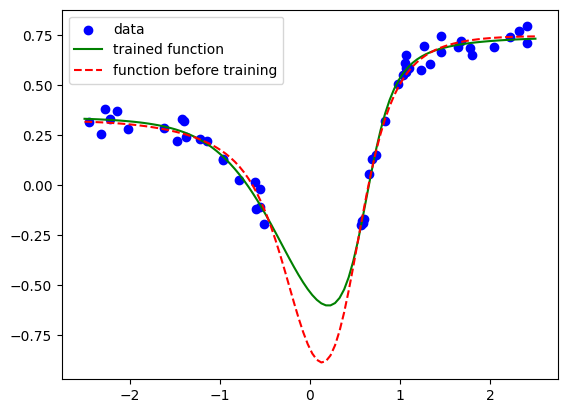

In [4]:
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_trained = model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="g", label="trained function")
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, label="function before training", linestyle="--", c="r")
plt.legend()

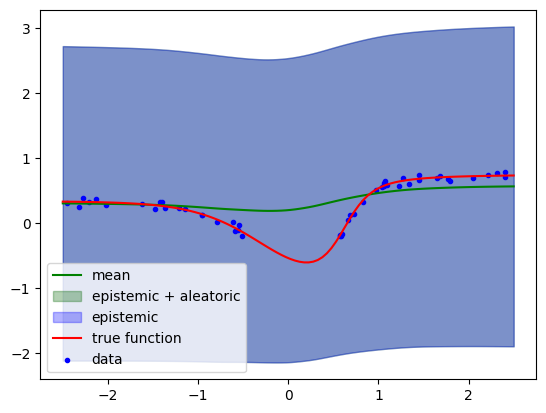

In [5]:
####################################
# Ok, we have trained the model. Now we can try to fit a Laplace approximation to the posterior
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, subspace_rank=0)

_=laplace.fit_subspace(fitting_type="GGN", xs=xs, ys=ys)
#_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)

integral_la, function_values_lp, weights_lp, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(model), xs=xs_plt)

means = integral_la.detach()[:, 0]
epistemic_var = (function_values_lp[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
aleatoric_var = target_sigma**2
plt.plot(xs_plt, means, c="g", label="mean")
plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.show()


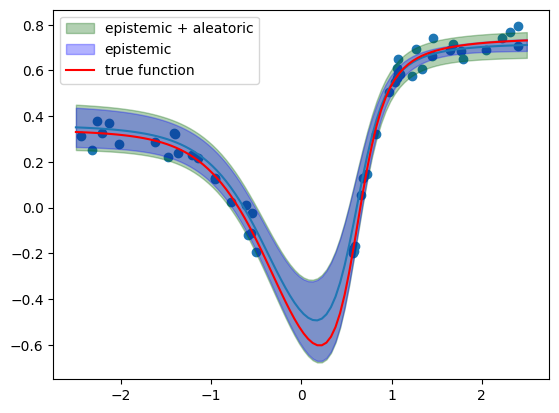

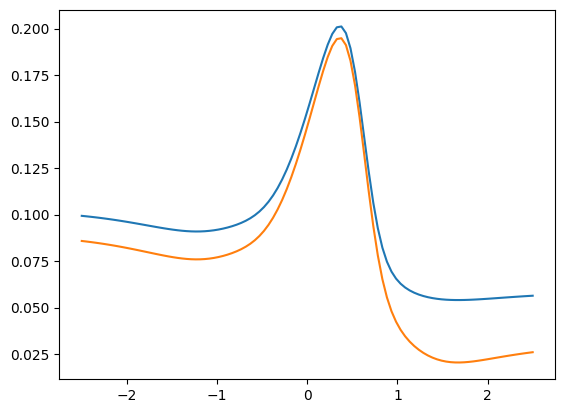

In [6]:
####################################
# Laplace subspace integration
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, n_posterior_samples=100, subspace_rank=1)

_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)

integral_la, function_values_lp, weights_lp, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(model), xs=xs_plt)

means = integral_la.detach()[:, 0]
epistemic_var = (function_values_lp[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
aleatoric_var = target_sigma**2
plt.scatter(xs[:, 0].detach(), ys.detach())
plt.plot(xs_plt[:, 0].detach(), means)
plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.legend()
plt.show()

plt.plot(xs_plt, np.sqrt(aleatoric_var + epistemic_var))
plt.plot(xs_plt, np.sqrt(epistemic_var))
plt.show()




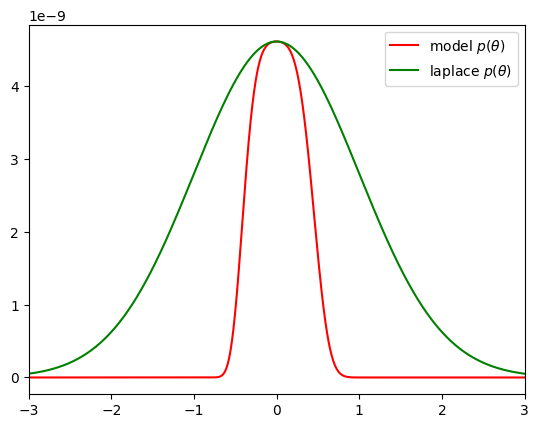

In [16]:
_, function_values_eval, weights_eval, posterior_samples_eval = integrator(sampler=laplace, model_func=make_functional_fwd_xs(model), xs=xs)


err = (function_values_eval[:,:, :]-ys).pow(2).sum(dim=[1,2])
log_prob = -err/(2 * tensify(target_sigma)**2) - ys.shape[0] * .5 * tensify(target_sigma) * torch.log(torch.tensor(2 * torch.pi)) 
val, ind = laplace.eps[:, 0].sort()
reg = log_prob[(laplace.eps[:, 0]**2).argmin()]
lp = torch.distributions.Normal(0,1).log_prob(laplace.eps[:, 0]) + reg - torch.distributions.Normal(0,1).log_prob(torch.tensor(0.0)) 
plt.plot(val.detach(), log_prob.exp()[ind].detach(), label="model $p(\\theta)$", c="r")
plt.plot(val.detach(), lp.exp()[ind].detach(), label="laplace $p(\\theta)$", c="g")
plt.legend()
plt.xlim(-3, 3)
plt.savefig(os.path.join(fig_folder, "laplace_prob.png"))
plt.show()

In [13]:
lp[ind]

tensor([-26.4520, -25.8806, -25.7740,  ..., -25.1226, -25.1430, -27.8552],
       grad_fn=<IndexBackward0>)